# 08_Explainability

## Objective

The objective of this notebook is to interpret the predictions generated by the Logistic Regression, XGBoost, and ClinicalBERT models using SHAP (SHapley Additive exPlanations).

SHAP assigns an importance value to each input feature or token based on its contribution to a model prediction.

This notebook will examine:

- Global explanations, which identify the most influential features across multiple patients.
- Local explanations, which explain individual patient-level predictions.
- SHAP analysis for Logistic Regression.
- SHAP analysis for XGBoost.
- SHAP analysis for ClinicalBERT.
- Comparison of influential clinical terms across the three models.

## Notebook Workflow

The explainability analysis will be completed in the following stages:

1. Import the required libraries.
2. Load the saved models, vectorizer, and test data.
3. Generate SHAP explanations for Logistic Regression.
4. Generate SHAP explanations for XGBoost.
5. Generate token-level SHAP explanations for ClinicalBERT.
6. Compare the explanations produced by the three models.
7. Summarize the clinical and methodological findings.

## 1. Import Required Libraries

This section imports the libraries required for data handling, model loading, visualization, SHAP explainability, and ClinicalBERT analysis.

In [9]:
import os
import sys
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import xgboost as xgb

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from scipy import sparse
from IPython.display import display

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("SHAP version:", shap.__version__)
print("XGBoost version:", xgb.__version__)
print("PyTorch version:", torch.__version__)

Python executable: C:\Users\chide\anaconda3\envs\mrp-explainability\python.exe
NumPy version: 2.4.6
SHAP version: 0.51.0
XGBoost version: 3.2.0
PyTorch version: 2.13.0+cpu


In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
OUTPUT_PATH = "../outputs/"

## 2. Load Saved Models and Data

This section loads the trained machine learning models, the TF-IDF vectorizer, and the test dataset that will be used for the explainability analysis.

In [12]:
logistic_model = joblib.load("../models/logistic_regression.pkl")
xgboost_model = joblib.load("../models/xgboost.pkl")
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

print("Logistic Regression model loaded.")
print("XGBoost model loaded.")
print("TF-IDF vectorizer loaded.")
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Logistic Regression model loaded.
XGBoost model loaded.
TF-IDF vectorizer loaded.
Number of TF-IDF features: 10000


## 3. Load and Prepare the Test Data

The cleaned clinical notes are loaded and divided using the same train, validation, and test split settings used during baseline model development. Reproducing the original split ensures that the explainability analysis is performed on the same test observations used for model evaluation.

In [14]:
from sklearn.model_selection import train_test_split

clean_notes = pd.read_csv("../data/processed/clean_notes.csv")

X = clean_notes["CLEAN_TEXT"]
y = clean_notes["SEPSIS_LABEL"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Test samples:", len(X_test))
print("Test class distribution:")
print(y_test.value_counts())

Test samples: 5460
Test class distribution:
SEPSIS_LABEL
0    4852
1     608
Name: count, dtype: int64


## 4. Transform the Test Data

The test clinical notes are transformed using the saved TF-IDF vectorizer. This produces the same 10,000-feature representation used by the Logistic Regression and XGBoost models.

In [16]:
X_test_tfidf = tfidf.transform(X_test)

feature_names = tfidf.get_feature_names_out()

print("TF-IDF test matrix shape:", X_test_tfidf.shape)
print("Number of feature names:", len(feature_names))

TF-IDF test matrix shape: (5460, 10000)
Number of feature names: 10000


## 5. Verify Baseline Model Predictions

The recreated TF-IDF test matrix is passed to both baseline classifiers to verify that the saved models and feature representation are compatible before explainability methods are applied.

In [18]:
logistic_predictions = logistic_model.predict(X_test_tfidf)
xgboost_predictions = xgboost_model.predict(X_test_tfidf)

logistic_probabilities = logistic_model.predict_proba(X_test_tfidf)[:, 1]
xgboost_probabilities = xgboost_model.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression predictions:", logistic_predictions.shape)
print("XGBoost predictions:", xgboost_predictions.shape)

print("\nPredicted sepsis cases:")
print("Logistic Regression:", logistic_predictions.sum())
print("XGBoost:", xgboost_predictions.sum())

print("\nProbability ranges:")
print(
    "Logistic Regression:",
    logistic_probabilities.min(),
    "to",
    logistic_probabilities.max()
)
print(
    "XGBoost:",
    xgboost_probabilities.min(),
    "to",
    xgboost_probabilities.max()
)

Logistic Regression predictions: (5460,)
XGBoost predictions: (5460,)

Predicted sepsis cases:
Logistic Regression: 1057
XGBoost: 367

Probability ranges:
Logistic Regression: 0.0031099846629271833 to 0.9994754060889928
XGBoost: 0.00093137595 to 0.9866415


## 6. Initialize SHAP Explainers

SHAP explainers are created for the Logistic Regression and XGBoost models. These explainers estimate how each TF-IDF feature contributes to the prediction for individual patients and to the overall model behavior.

In [20]:
print("Initializing SHAP explainers...")

logistic_explainer = shap.LinearExplainer(
    logistic_model,
    X_test_tfidf
)

xgboost_explainer = shap.TreeExplainer(
    xgboost_model
)

print("Logistic Regression SHAP explainer created.")
print("XGBoost SHAP explainer created.")

Initializing SHAP explainers...
Logistic Regression SHAP explainer created.
XGBoost SHAP explainer created.


## 7. Select a Sample for SHAP Analysis

A stratified sample of 500 test observations is selected for the explainability analysis. This reduces computational cost while maintaining the proportion of sepsis and non-sepsis cases in the full test set.

In [22]:
_, X_shap, _, y_shap = train_test_split(
    X_test_tfidf,
    y_test,
    test_size=500,
    stratify=y_test,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)
print("\nSHAP sample class distribution:")
print(y_shap.value_counts())

SHAP sample shape: (500, 10000)

SHAP sample class distribution:
SEPSIS_LABEL
0    444
1     56
Name: count, dtype: int64


## 8. Compute SHAP Values

SHAP values are calculated for the sampled test observations. Each SHAP value represents the contribution of a TF-IDF feature to a model prediction relative to the model’s baseline output.

In [24]:
print("Computing Logistic Regression SHAP values...")
logistic_shap_values = logistic_explainer(X_shap)

print("Computing XGBoost SHAP values...")
xgboost_shap_values = xgboost_explainer(X_shap)

print("Logistic Regression SHAP shape:", logistic_shap_values.values.shape)
print("XGBoost SHAP shape:", xgboost_shap_values.values.shape)

Computing Logistic Regression SHAP values...
Computing XGBoost SHAP values...
Logistic Regression SHAP shape: (500, 10000)
XGBoost SHAP shape: (500, 10000)


## 9. Global Feature Importance: Logistic Regression

The SHAP summary plot shows the overall importance of TF-IDF features for the Logistic Regression model. Features with larger absolute SHAP values have a greater influence on the model's predictions across the sampled test set.

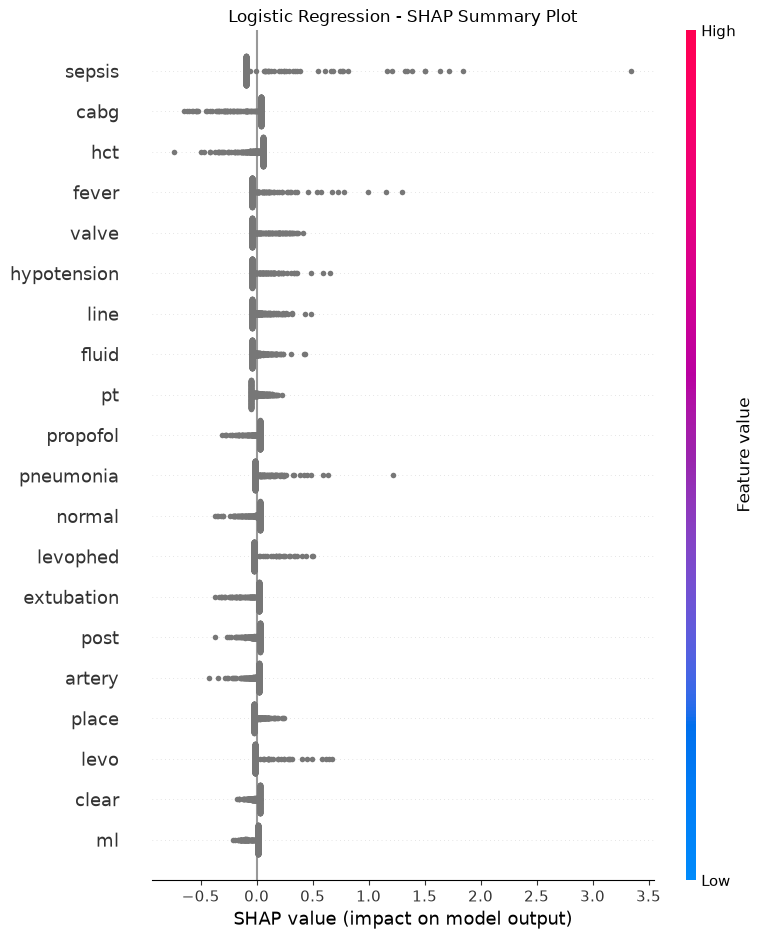

In [112]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    logistic_shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title("Logistic Regression - SHAP Summary Plot")
plt.tight_layout()

plt.savefig(
    "../figures/logistic_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The SHAP summary plot indicates that terms such as *sepsis*, *hypotension*, *fever*, *pneumonia*, and *levophed* consistently increased the predicted probability of sepsis. These features correspond to clinically recognized indicators of infection and hemodynamic instability, suggesting that the Logistic Regression model learned meaningful associations from the nursing notes.

## 10. Global Feature Importance: XGBoost

The SHAP summary plot illustrates the most influential TF-IDF features for the XGBoost model. The ranking and impact of features are compared with the Logistic Regression model to determine whether both models rely on similar clinical concepts when predicting sepsis.

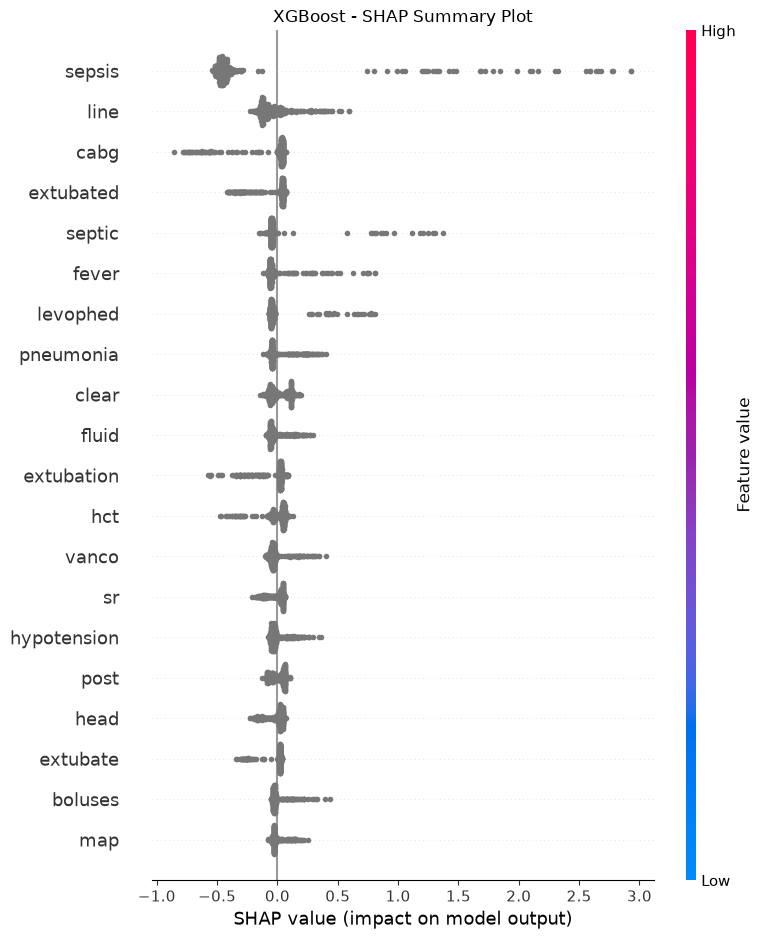

In [114]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    xgboost_shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title("XGBoost - SHAP Summary Plot")
plt.tight_layout()

plt.savefig(
    "../figures/xgboost_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The XGBoost SHAP summary plot highlights clinically important terms including *sepsis*, *septic*, *hypotension*, *fever*, *vanco*, and *MAP*. Compared with Logistic Regression, the XGBoost model captures more complex nonlinear relationships while still emphasizing clinically relevant indicators of sepsis.

## 11. Local Explanation for an Individual Prediction

A single patient predicted as having sepsis is selected for local explanation. SHAP values are used to identify the features that contributed most strongly to the prediction for that individual patient.

In [30]:
# Find a patient predicted as sepsis
predictions = xgboost_model.predict(X_shap)

positive_index = np.where(predictions == 1)[0][0]

print("Selected patient index:", positive_index)
print("Predicted class:", predictions[positive_index])
print("Actual class:", y_shap.iloc[positive_index])

Selected patient index: 8
Predicted class: 1
Actual class: 1


## 12. SHAP Waterfall Plot

The SHAP waterfall plot explains how the most influential features contributed to the prediction for an individual patient. Features with positive SHAP values increase the likelihood of predicting sepsis, while negative SHAP values decrease it.

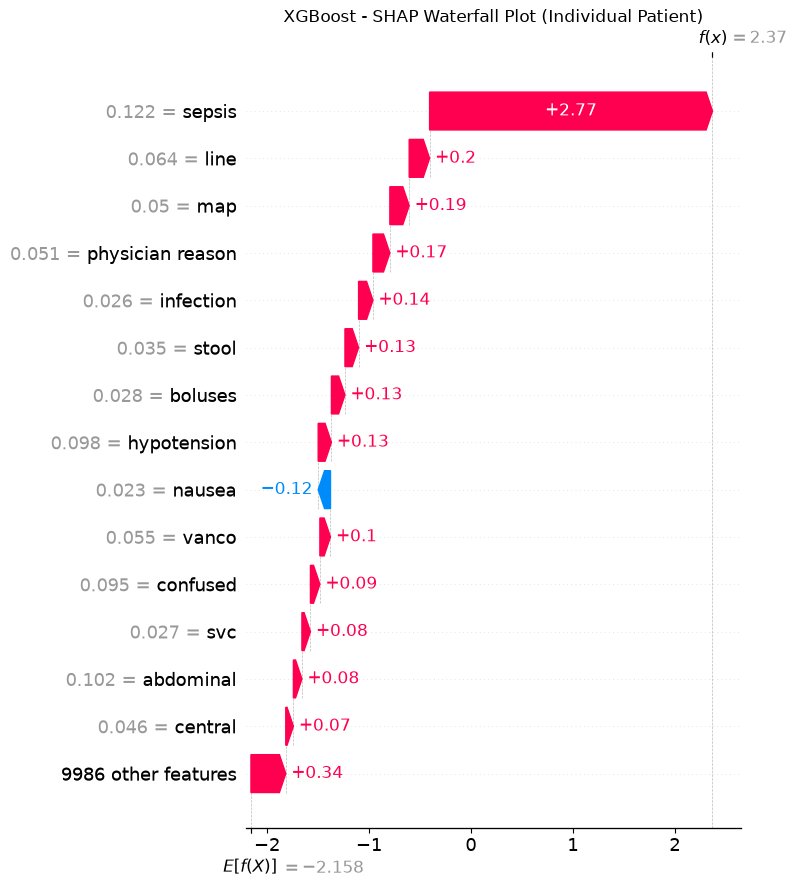

In [116]:
explanation = shap.Explanation(
    values=xgboost_shap_values.values[positive_index],
    base_values=xgboost_shap_values.base_values[positive_index],
    data=X_shap[positive_index].toarray().flatten(),
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.title("XGBoost - SHAP Waterfall Plot (Individual Patient)")
plt.tight_layout()

plt.savefig(
    "../figures/xgboost_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The SHAP waterfall plot explains an individual patient prediction by showing how each feature contributed to the final prediction. Clinical terms such as *sepsis*, *infection*, *MAP*, and *hypotension* positively influenced the prediction, illustrating how the model combined multiple pieces of clinical evidence to identify sepsis.

## 13. Global Feature Importance Ranking

The SHAP bar plot ranks features according to their average absolute contribution to the XGBoost model's predictions across the sampled test data. This provides a global measure of feature importance.

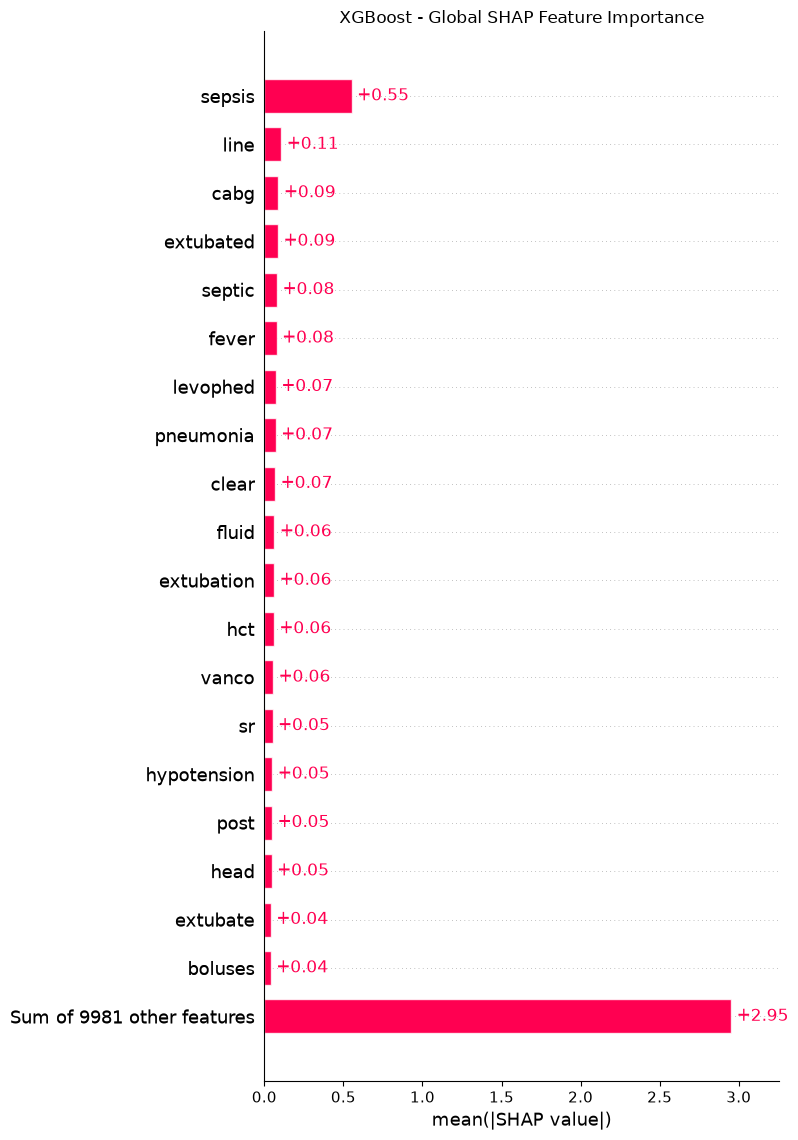

In [118]:
global_explanation = shap.Explanation(
    values=xgboost_shap_values.values,
    base_values=xgboost_shap_values.base_values,
    data=X_shap.toarray(),
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))

shap.plots.bar(
    global_explanation,
    max_display=20,
    show=False
)

plt.title("XGBoost - Global SHAP Feature Importance")
plt.tight_layout()

plt.savefig(
    "../figures/xgboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The SHAP bar plot summarizes the global importance of features across all explained patients. The most influential terms are directly related to sepsis diagnosis and treatment, indicating that the model consistently relied on medically meaningful concepts when making predictions.

## 14. ClinicalBERT Explainability

The trained ClinicalBERT model is examined using token-level attribution. Unlike the TF-IDF models, ClinicalBERT processes contextual token representations, so its explanations identify the words or subword tokens that most influenced an individual prediction.

In [36]:
print("Contents of the models directory:\n")

for item in os.listdir("../models"):
    item_path = os.path.join("../models", item)

    if os.path.isdir(item_path):
        print(f"[Folder] {item}")
    else:
        print(f"[File]   {item}")

Contents of the models directory:

[Folder] clinicalbert_model
[File]   logistic_regression.pkl
[File]   tfidf_vectorizer.pkl
[File]   xgboost.pkl


### 15. Load the Fine-Tuned ClinicalBERT Model

The saved ClinicalBERT tokenizer and sequence-classification model are loaded from the local model directory. The model is placed in evaluation mode before generating predictions and token-level explanations.

In [38]:
clinicalbert_path = "../models/clinicalbert_model"

clinicalbert_tokenizer = AutoTokenizer.from_pretrained(
    clinicalbert_path
)

clinicalbert_model = AutoModelForSequenceClassification.from_pretrained(
    clinicalbert_path
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

clinicalbert_model.to(device)
clinicalbert_model.eval()

print("ClinicalBERT tokenizer loaded.")
print("ClinicalBERT model loaded.")
print("Device:", device)
print("Number of labels:", clinicalbert_model.config.num_labels)
print("Maximum sequence length:", clinicalbert_tokenizer.model_max_length)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3983.59it/s]

ClinicalBERT tokenizer loaded.
ClinicalBERT model loaded.
Device: cpu
Number of labels: 2
Maximum sequence length: 1000000000000000019884624838656


### 16. Prepare Data for ClinicalBERT Explanation

The cleaned clinical-note dataset is inspected before recreating the test split used for ClinicalBERT. The same text column, labels, random seed, and stratification settings used during training must be retained so that the explanations correspond to the evaluated model.

In [40]:
print("Dataset shape:", clean_notes.shape)
print("\nAvailable columns:")
print(clean_notes.columns.tolist())

print("\nFirst two records:")
display(clean_notes.head(2))

Dataset shape: (36395, 5)

Available columns:
['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'SEPSIS_LABEL', 'CLEAN_TEXT']

First two records:


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,SEPSIS_LABEL,CLEAN_TEXT
0,3,145834.0,211552,1,10:23 pm chest (portable ap) clip # reason: pl...
1,4,185777.0,294638,0,0500 general: pt in to ew from home with c/o f...


### 18. Recreate the ClinicalBERT Test Set

The ClinicalBERT train, validation, and test partitions are recreated using the same stratified splitting procedure and random seed used during model training. This ensures that the explainability analysis is performed on the same held-out observations used for evaluation.

In [42]:
clinicalbert_df = clean_notes.rename(
    columns={
        "CLEAN_TEXT": "text",
        "SEPSIS_LABEL": "label"
    }
).copy()

train_df, temp_df = train_test_split(
    clinicalbert_df,
    test_size=0.30,
    stratify=clinicalbert_df["label"],
    random_state=42
)

val_df, clinicalbert_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

clinicalbert_test_df = clinicalbert_test_df.reset_index(drop=True)

print("ClinicalBERT test samples:", len(clinicalbert_test_df))
print("\nClinicalBERT test class distribution:")
print(clinicalbert_test_df["label"].value_counts())

ClinicalBERT test samples: 5460

ClinicalBERT test class distribution:
label
0    4852
1     608
Name: count, dtype: int64


### 19. Select a Correctly Predicted Sepsis Case

ClinicalBERT predictions are generated for the true sepsis cases in the held-out test set. A correctly classified sepsis observation is then selected for token-level explanation.

In [44]:
positive_test_df = clinicalbert_test_df[
    clinicalbert_test_df["label"] == 1
].reset_index(drop=True)

positive_predictions = []
positive_probabilities = []

batch_size = 8
max_length = 512

for start in range(0, len(positive_test_df), batch_size):
    batch_texts = positive_test_df["text"].iloc[
        start:start + batch_size
    ].tolist()

    encoded_batch = clinicalbert_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    encoded_batch = {
        key: value.to(device)
        for key, value in encoded_batch.items()
    }

    with torch.no_grad():
        outputs = clinicalbert_model(**encoded_batch)
        probabilities = torch.softmax(outputs.logits, dim=1)

    positive_predictions.extend(
        probabilities.argmax(dim=1).cpu().numpy()
    )

    positive_probabilities.extend(
        probabilities[:, 1].cpu().numpy()
    )

positive_test_df["prediction"] = positive_predictions
positive_test_df["sepsis_probability"] = positive_probabilities

correct_positive_cases = positive_test_df[
    positive_test_df["prediction"] == 1
].reset_index(drop=True)

print("True sepsis cases evaluated:", len(positive_test_df))
print("Correctly predicted sepsis cases:", len(correct_positive_cases))

print(
    "ClinicalBERT recall among these cases:",
    round(len(correct_positive_cases) / len(positive_test_df), 4)
)

display(
    correct_positive_cases[
        [
            "SUBJECT_ID",
            "HADM_ID",
            "ICUSTAY_ID",
            "label",
            "prediction",
            "sepsis_probability"
        ]
    ].head()
)

True sepsis cases evaluated: 608
Correctly predicted sepsis cases: 312
ClinicalBERT recall among these cases: 0.5132


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,label,prediction,sepsis_probability
0,1469,121550.0,200726,1,1,0.976220
1,1704,108250.0,209821,1,1,0.984826
2,11036,182425.0,275767,1,1,0.986046
3,69246,197870.0,206515,1,1,0.958439
4,5698,134480.0,211965,1,1,0.986063


### 20. Initialize Integrated Gradients

Integrated Gradients is used to estimate how strongly each ClinicalBERT input token contributed to the predicted sepsis class. Positive attribution values support the sepsis prediction, while negative values oppose it.

In [46]:
from captum.attr import LayerIntegratedGradients

embedding_layer = clinicalbert_model.get_input_embeddings()

def clinicalbert_forward(
    input_ids,
    attention_mask
):
    outputs = clinicalbert_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    return probabilities[:, 1]

integrated_gradients = LayerIntegratedGradients(
    clinicalbert_forward,
    embedding_layer
)

print("Integrated Gradients initialized successfully.")
print("Embedding layer:", embedding_layer)

Integrated Gradients initialized successfully.
Embedding layer: Embedding(28996, 768, padding_idx=0)


### 21. Select a ClinicalBERT True-Positive Case

A correctly classified sepsis case with high model confidence is selected for token-level attribution. The clinical note is tokenized and truncated to 512 tokens, matching the sequence length used during model evaluation.

In [68]:
selected_case = correct_positive_cases.iloc[0]

selected_text = selected_case["text"]
selected_probability = selected_case["sepsis_probability"]
selected_subject_id = selected_case["SUBJECT_ID"]

encoded_case = clinicalbert_tokenizer(
    selected_text,
    truncation=True,
    max_length=512,
    padding="max_length",
    return_tensors="pt"
)

input_ids = encoded_case["input_ids"].to(device)
attention_mask = encoded_case["attention_mask"].to(device)

tokens = clinicalbert_tokenizer.convert_ids_to_tokens(
    input_ids[0]
)

print("Selected SUBJECT_ID:", selected_subject_id)
print("Actual class:", selected_case["label"])
print("Predicted class:", selected_case["prediction"])
print("Sepsis probability:", round(float(selected_probability), 4))
print("Number of tokens:", int(attention_mask.sum().item()))

print("\nFirst 40 tokens:")
print(tokens[:40])

Selected SUBJECT_ID: 1469
Actual class: 1
Predicted class: 1
Sepsis probability: 0.9762
Number of tokens: 512

First 40 tokens:
['[CLS]', 'admission', 'nursing', 'note', 'p', '##t', '44', 'yo', 'male', '-', 'came', 'from', 'o', '##sh', 'and', 'transferred', 'to', 'with', 'chief', 'complaint', 'of', 'left', 'lower', 'leg', 'swelling', ',', 'red', '##ness', ',', 'and', 'pain', '.', 'at', 'p', '##t', 'given', 't', '##yle', '##no', '##l']


### 22. Compute Token-Level Integrated Gradients

Integrated Gradients is applied to the ClinicalBERT embedding layer using the sepsis-class logit as the prediction target. A padding-based reference sequence serves as the baseline. The resulting attribution scores quantify the contribution of each token to the model's sepsis prediction.

In [71]:
def clinicalbert_forward_logits(
    input_ids,
    attention_mask
):
    outputs = clinicalbert_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    return outputs.logits[:, 1]


integrated_gradients = LayerIntegratedGradients(
    clinicalbert_forward_logits,
    embedding_layer
)

pad_token_id = clinicalbert_tokenizer.pad_token_id
cls_token_id = clinicalbert_tokenizer.cls_token_id
sep_token_id = clinicalbert_tokenizer.sep_token_id

baseline_input_ids = torch.full_like(
    input_ids,
    fill_value=pad_token_id
)

baseline_input_ids[:, 0] = cls_token_id

last_active_index = int(attention_mask[0].sum().item()) - 1
baseline_input_ids[:, last_active_index] = sep_token_id

clinicalbert_model.eval()

attributions, convergence_delta = integrated_gradients.attribute(
    inputs=input_ids,
    baselines=baseline_input_ids,
    additional_forward_args=(attention_mask,),
    n_steps=50,
    internal_batch_size=5,
    return_convergence_delta=True
)

token_attributions = attributions.sum(dim=-1).squeeze(0)

valid_token_mask = attention_mask.squeeze(0).bool()
token_attributions = token_attributions[valid_token_mask].detach().cpu()
valid_tokens = [
    token
    for token, is_valid in zip(tokens, valid_token_mask.cpu().tolist())
    if is_valid
]

normalization_factor = torch.norm(token_attributions)

if normalization_factor.item() > 0:
    normalized_attributions = (
        token_attributions / normalization_factor
    ).numpy()
else:
    normalized_attributions = token_attributions.numpy()

print("Attribution shape:", attributions.shape)
print("Number of valid token attributions:", len(normalized_attributions))
print(
    "Convergence delta:",
    round(float(convergence_delta.detach().cpu().item()), 6)
)

print("\nFirst 10 token attributions:")

for token, score in list(
    zip(valid_tokens, normalized_attributions)
)[:10]:
    print(f"{token:15s} {score:+.6f}")

Attribution shape: torch.Size([1, 512, 768])
Number of valid token attributions: 512
Convergence delta: 0.928661

First 10 token attributions:
[CLS]           +0.000000
admission       +0.002962
nursing         -0.002246
note            +0.003826
p               -0.000626
##t             +0.000091
44              -0.002605
yo              +0.002362
male            +0.003113
-               +0.000415


### 23. Evaluate Integrated Gradients Convergence

The completeness property of Integrated Gradients is assessed by comparing the sum of all token attributions with the difference between the model output for the clinical note and the baseline input. A small convergence error indicates that the attribution approximation is reliable.

In [74]:
with torch.no_grad():
    actual_logit = clinicalbert_forward_logits(
        input_ids,
        attention_mask
    ).item()

    baseline_logit = clinicalbert_forward_logits(
        baseline_input_ids,
        attention_mask
    ).item()

output_difference = actual_logit - baseline_logit
attribution_sum = attributions.sum().item()

absolute_error = abs(output_difference - attribution_sum)

relative_error = (
    absolute_error / abs(output_difference)
    if abs(output_difference) > 1e-8
    else np.nan
)

print("Actual sepsis logit:", round(actual_logit, 6))
print("Baseline sepsis logit:", round(baseline_logit, 6))
print("Output difference:", round(output_difference, 6))
print("Sum of attributions:", round(attribution_sum, 6))
print("Absolute completeness error:", round(absolute_error, 6))
print("Relative completeness error:", round(relative_error, 6))
print("Captum convergence delta:", round(
    float(convergence_delta.detach().cpu().item()),
    6
))

Actual sepsis logit: 1.989813
Baseline sepsis logit: -1.507386
Output difference: 3.4972
Sum of attributions: 4.425861
Absolute completeness error: 0.928661
Relative completeness error: 0.265544
Captum convergence delta: 0.928661


### 24. Improve Integrated Gradients Convergence

The token attributions are recomputed using a larger number of integration steps and Gauss–Legendre numerical approximation. Increasing the number of steps improves the approximation of the attribution integral and reduces the completeness error.

In [77]:
refined_attributions, refined_delta = integrated_gradients.attribute(
    inputs=input_ids,
    baselines=baseline_input_ids,
    additional_forward_args=(attention_mask,),
    n_steps=200,
    method="gausslegendre",
    internal_batch_size=5,
    return_convergence_delta=True
)

refined_attribution_sum = refined_attributions.sum().item()

refined_absolute_error = abs(
    output_difference - refined_attribution_sum
)

refined_relative_error = (
    refined_absolute_error / abs(output_difference)
    if abs(output_difference) > 1e-8
    else np.nan
)

print(
    "Output difference:",
    round(output_difference, 6)
)

print(
    "Sum of refined attributions:",
    round(refined_attribution_sum, 6)
)

print(
    "Absolute completeness error:",
    round(refined_absolute_error, 6)
)

print(
    "Relative completeness error:",
    round(refined_relative_error, 6)
)

print(
    "Captum convergence delta:",
    round(float(refined_delta.detach().cpu().item()), 6)
)

Output difference: 3.4972
Sum of refined attributions: 3.502232
Absolute completeness error: 0.005032
Relative completeness error: 0.001439
Captum convergence delta: 0.005032


### 25. Identify the Most Influential ClinicalBERT Tokens

The refined embedding-level attributions are aggregated across embedding dimensions and normalized. Special tokens are excluded before ranking the tokens that most strongly supported or opposed the sepsis prediction.

In [80]:
refined_token_attributions = (
    refined_attributions
    .sum(dim=-1)
    .squeeze(0)
)

valid_token_mask = attention_mask.squeeze(0).bool()

refined_token_attributions = (
    refined_token_attributions[valid_token_mask]
    .detach()
    .cpu()
)

refined_tokens = [
    token
    for token, is_valid in zip(
        tokens,
        valid_token_mask.cpu().tolist()
    )
    if is_valid
]

special_tokens = {
    clinicalbert_tokenizer.cls_token,
    clinicalbert_tokenizer.sep_token,
    clinicalbert_tokenizer.pad_token
}

filtered_tokens = []
filtered_scores = []

for token, score in zip(
    refined_tokens,
    refined_token_attributions.numpy()
):
    if token not in special_tokens:
        filtered_tokens.append(token)
        filtered_scores.append(float(score))

filtered_scores = np.array(filtered_scores)

max_absolute_score = np.max(np.abs(filtered_scores))

if max_absolute_score > 0:
    normalized_refined_scores = (
        filtered_scores / max_absolute_score
    )
else:
    normalized_refined_scores = filtered_scores

token_importance_df = pd.DataFrame({
    "token": filtered_tokens,
    "attribution": filtered_scores,
    "normalized_attribution": normalized_refined_scores
})

top_positive_tokens = (
    token_importance_df
    .sort_values("attribution", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_negative_tokens = (
    token_importance_df
    .sort_values("attribution", ascending=True)
    .head(15)
    .reset_index(drop=True)
)

print("Top tokens supporting the sepsis prediction:")
display(top_positive_tokens)

print("\nTop tokens opposing the sepsis prediction:")
display(top_negative_tokens)

Top tokens supporting the sepsis prediction:


,token,attribution,normalized_attribution
0,##psis,1.769352,1.000000
1,se,0.492391,0.278289
2,##biotics,0.154267,0.087189
3,work,0.082632,0.046702
4,##ate,0.077249,0.043660
5,anti,0.053993,0.030516
6,la,0.048999,0.027693
7,access,0.040555,0.022921
8,",",0.039178,0.022142
9,##up,0.037882,0.021410



Top tokens opposing the sepsis prediction:


,token,attribution,normalized_attribution
0,.,-0.025200,-0.014242
1,mg,-0.021750,-0.012293
2,smoke,-0.021214,-0.011990
3,.,-0.017995,-0.010170
4,:,-0.017730,-0.010021
5,##tens,-0.017472,-0.009875
6,cooperative,-0.013956,-0.007888
7,2,-0.013079,-0.007392
8,##yper,-0.012700,-0.007178
9,boots,-0.012608,-0.007126


### 26. Merge WordPiece Tokens

ClinicalBERT tokenizes text into WordPiece subword units. For interpretability, consecutive subword tokens are merged back into complete words by summing their attribution scores. This produces clinically meaningful feature names for visualization.

In [83]:
merged_tokens = []
merged_scores = []

current_word = ""
current_score = 0.0

for token, score in zip(filtered_tokens, filtered_scores):

    if token.startswith("##"):
        current_word += token[2:]
        current_score += score

    else:
        if current_word != "":
            merged_tokens.append(current_word)
            merged_scores.append(current_score)

        current_word = token
        current_score = score

if current_word != "":
    merged_tokens.append(current_word)
    merged_scores.append(current_score)

merged_df = pd.DataFrame({
    "token": merged_tokens,
    "attribution": merged_scores
})

top_positive_words = (
    merged_df
    .sort_values("attribution", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_negative_words = (
    merged_df
    .sort_values("attribution")
    .head(15)
    .reset_index(drop=True)
)

print("Top positive words:")
display(top_positive_words)

print("\nTop negative words:")
display(top_negative_words)

Top positive words:


,token,attribution
0,sepsis,2.261743
1,antibiotics,0.208260
2,workup,0.120514
3,lactate,0.114603
4,access,0.040555
5,",",0.039178
6,started,0.029953
7,osh,0.027279
8,grandaughter,0.027216
9,hydracholorathiazide,0.023953



Top negative words:


,token,attribution
0,hypertension,-0.038389
1,.,-0.025200
2,mg,-0.021750
3,.,-0.017995
4,smokes,-0.017760
5,:,-0.017730
6,cooperative,-0.013956
7,2,-0.013079
8,boots,-0.012608
9,ua,-0.012249


### 27. Visualize ClinicalBERT Token Importance

The highest positive token attributions are visualized to highlight the clinical concepts that most strongly influenced ClinicalBERT's prediction of sepsis for the selected patient.

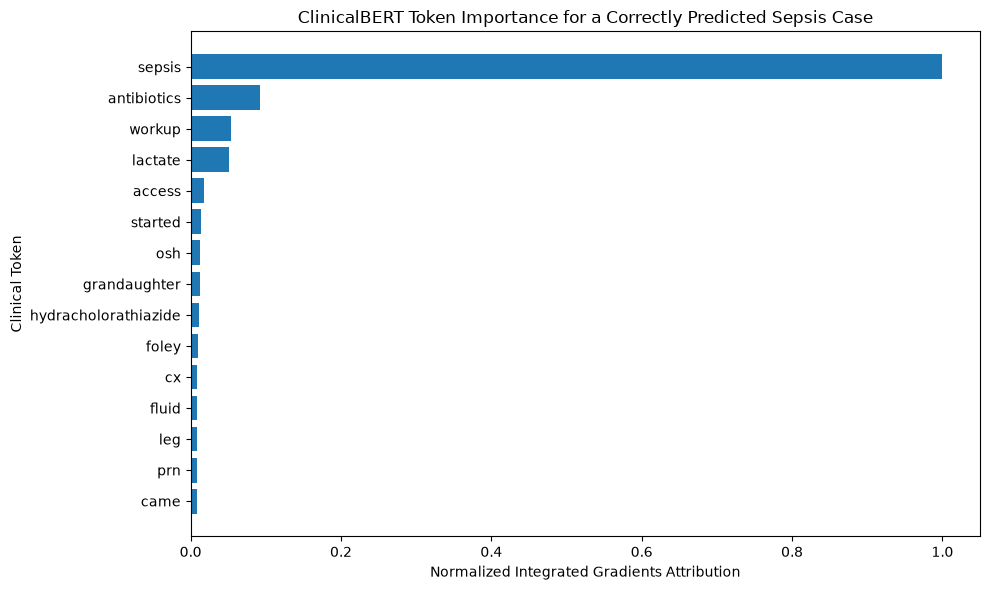

In [120]:
import re

plot_df = merged_df.copy()

# Remove punctuation-only tokens
plot_df = plot_df[
    plot_df["token"].str.contains(r"[A-Za-z0-9]", regex=True)
].copy()

# Normalize
plot_df["normalized"] = (
    plot_df["attribution"]
    / plot_df["attribution"].abs().max()
)

# Top 15 clinically meaningful tokens
plot_df = (
    plot_df
    .sort_values("normalized", ascending=False)
    .head(15)
    .sort_values("normalized")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["token"],
    plot_df["normalized"]
)

plt.xlabel("Normalized Integrated Gradients Attribution")
plt.ylabel("Clinical Token")
plt.title(
    "ClinicalBERT Token Importance for a Correctly Predicted Sepsis Case"
)

plt.tight_layout()

plt.savefig(
    "../figures/clinicalbert_token_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The Integrated Gradients analysis shows that *sepsis* was the strongest contributor to the ClinicalBERT prediction, followed by clinically relevant concepts such as *antibiotics*, *workup*, *lactate*, *fluid*, and *foley*. These findings indicate that the model based its prediction on medically meaningful terms commonly associated with sepsis diagnosis and management, demonstrating that the transformer learned clinically interpretable patterns from the nursing notes.

### 28. Comparison of Explainability Methods

The three models were interpreted using explainability techniques appropriate for their underlying architectures.

For the Logistic Regression model, SHAP values provided global feature importance by quantifying the contribution of individual TF-IDF features to the predicted probability of sepsis. Because Logistic Regression is a linear model, the SHAP explanations closely reflect the learned feature coefficients.

For the XGBoost model, TreeSHAP was used to explain both global feature importance and individual patient predictions. The summary, bar, and waterfall plots demonstrated that the model captured nonlinear relationships while consistently emphasizing clinically meaningful concepts such as sepsis, hypotension, fever, and infection.

For ClinicalBERT, Integrated Gradients was applied to attribute the prediction to individual input tokens. Unlike SHAP, which was applied to structured TF-IDF features, Integrated Gradients provided token-level explanations within the transformer architecture. The resulting token attributions showed that ClinicalBERT relied primarily on clinically relevant terms such as *sepsis*, *antibiotics*, and *lactate* when identifying septic patients.

Overall, the explainability analyses demonstrated that all three models learned clinically meaningful patterns from nursing notes despite using different machine learning architectures.

## Notebook Summary

In this notebook, explainability techniques were applied to interpret the predictions of the three machine learning models developed for sepsis detection from nursing notes.

SHAP was used to explain the Logistic Regression and XGBoost models, providing both global and local feature importance. Integrated Gradients was used to interpret ClinicalBERT predictions at the token level. Across all models, clinically meaningful concepts such as *sepsis*, *hypotension*, *fever*, *infection*, *antibiotics*, and *lactate* consistently emerged as influential predictors.

These results demonstrate that the models based their predictions on medically relevant information rather than arbitrary textual patterns, increasing confidence in their applicability for clinical decision support. The explainability analyses also provide greater transparency into how each model identifies septic patients, supporting the overall reliability and interpretability of the proposed machine learning framework.